# Offshore wind NPV simulation

Run the offshore wind electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity_npv_monte_carlo import simulate_wind_offshore_npv


In [2]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_wind_offshore_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,wind_offshore,1000000.0,3850.0,259.74026,259740.25974,2607.016186,41.695996,7.416098,0.0,...,94070000.0,1.083013e+07,7.416098e+06,0.0,0.0,7.582377e+07,1.322548e+08,25000000.0,5.290190,0.000005
1,1,wind_offshore,1000000.0,3850.0,259.74026,259740.25974,2527.637351,38.220750,8.066217,0.0,...,94070000.0,9.927468e+06,8.066217e+06,0.0,0.0,7.607632e+07,1.555685e+08,25000000.0,6.222738,0.000006
2,2,wind_offshore,1000000.0,3850.0,259.74026,259740.25974,2482.698454,37.794660,7.311703,0.0,...,94070000.0,9.816795e+06,7.311703e+06,0.0,0.0,7.694150e+07,1.764766e+08,25000000.0,7.059063,0.000007
3,3,wind_offshore,1000000.0,3850.0,259.74026,259740.25974,2861.117210,36.573909,7.893568,0.0,...,94070000.0,9.499717e+06,7.893568e+06,0.0,0.0,7.667672e+07,7.535945e+07,25000000.0,3.014378,0.000003
4,4,wind_offshore,1000000.0,3850.0,259.74026,259740.25974,2396.642051,42.848887,7.229887,0.0,...,94070000.0,1.112958e+07,7.229887e+06,0.0,0.0,7.571053e+07,1.856886e+08,25000000.0,7.427542,0.000007


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1000000.000000
mean,76.917009,3.076680,0.000003
std,91.102530,3.644101,0.000004
min,-122.051147,-4.882046,-0.000005
5%,-64.375433,-2.575017,-0.000003
50%,76.847511,3.073900,0.000003
95%,218.398020,8.735921,0.000009
max,270.657437,10.826297,0.000011


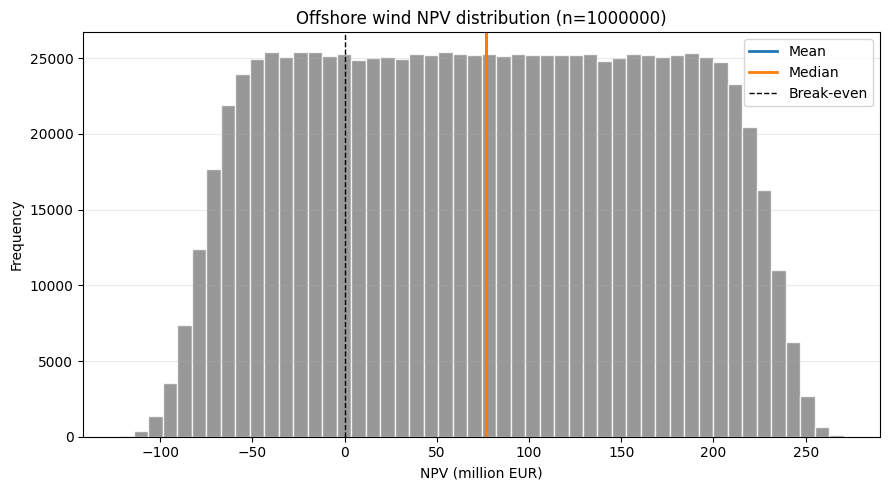

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Offshore wind NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


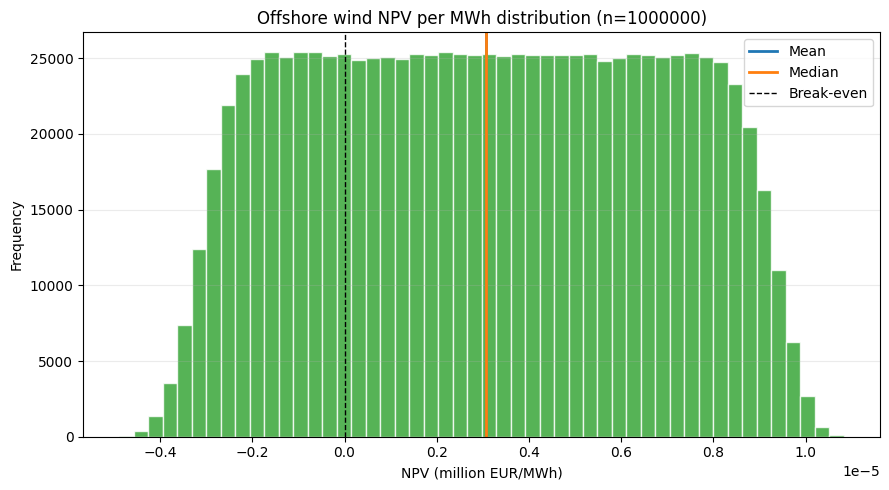

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Offshore wind NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur        10.466439
annual_variable_opex_eur      8.266572
annual_fuel_cost_eur          0.000000
annual_emissions_cost_eur     0.000000
annual_net_cash_flow_eur     75.336989
Name: Mean annual value, million EUR, dtype: float64